In [1]:
sys.path.append("..")

In [2]:
import qfi

In [3]:
import numpy as np
from numpy import array, arange, zeros, ones, log2, outer, full, sqrt, trace, linspace
import pickle

from matplotlib import pyplot as plt
plt.rcParams['font.family']='serif'
plt.rcParams['axes.unicode_minus']=True
plt.rcParams.update({'font.size': 18, 'text.latex.preamble': r'\usepackage{amsfonts, amsmath}', 'text.usetex': True})

In [4]:
def partial_trace(dm, m=None, n=None, subsystem=0):
    """ Simple and fast, but cuts only in halves. """
    if (m is None) or (n is None): # cut in equal halves
        N = log2(len(dm))
        m = int(N / 2)
        n = int(N - m)
        m = 2**m
        n = 2**n
    if subsystem == 0:
        return trace(dm.reshape((m, n, m, n)), axis1=0, axis2=2)
    elif subsystem == 1:
        return trace(dm.reshape((m, n, m, n)), axis1=1, axis2=3)

def concurrence_pure(sv):
    dm = outer(sv, sv.conj())
    dm_red = partial_trace(dm)
    return sqrt(2*(1 - trace(dm_red@dm_red).real))

In [5]:
n = 7
d = 2**n
x_list = qfi.mixer_list(n)
state_ini = full(d, 1/sqrt(d))

# CUT

In [6]:
prob_list = np.round(arange(0.3, 1.0, 0.1), 2)
p_min_cut = 1
p_max_cut = 70
s_min_cut = 0
s_max_cut = 49
r_min_cut = 0
r_max_cut = 19

In [14]:
# path = "/home/investigator/Work/qaoa-qfi/Data/Raw/Raw/CUT/Random_graphs/"
# pref = "maxcut-random_graphs-"
# post = "-prevsol" 

# ent_list_cut = zeros([len(prob_list), s_max_cut - s_min_cut + 1, r_max_cut - r_min_cut + 1, p_max_cut - p_min_cut + 1])
# EQD_list_cut = zeros([len(prob_list), s_max_cut - s_min_cut + 1, r_max_cut - r_min_cut + 1])

# for prob_i in range(len(prob_list)):
#     folder = 'n=%d-prob=%.2f-p=(%d,%d)-prevsol/' %(n, prob_list[prob_i], p_min_cut, p_max_cut)
#     for s in range(s_min_cut, s_max_cut + 1):
#         for r in range(r_min_cut, r_max_cut + 1):
#             print("prob=%.2f | s=%d | r=%d" %(prob_list[prob_i], s, r), end="\r")
#             try:
#                 file_name = path + folder + pref + "n=%d-prob=%.2f-p=(%d,%d)-s=%d-r=%d" %(n, prob_list[prob_i], p_min_cut, p_max_cut, s, r) + post + ".npy"
#                 _, _, _, _, _, _, _, H_diag_r, _, _, _, _, _, _, xfs_r, EQD_r = np.load(file_name, allow_pickle=True)
#                 EQD_list_cut[prob_i][s][r] = EQD_r
#             except:
#                 print("\tNo data for (m=%d, s=%d, r=%d)" %(prob_list[prob_i], s, r))
#                 EQD_list_cut[prob_i][s][r] = 2**n
#             xfs_r_cop = list(xfs_r)
#             for p_i in range(p_max_cut - p_min_cut + 1):
#                 if np.linalg.norm(xfs_r_cop[p_i]) < 1e-9:
#                     xfs_r_cop[p_i][:2*p_i] = xfs_r_cop[p_i - 1]
#                 sv = qfi.qaoa_vec(xfs_r_cop[p_i], n, x_list, H_diag_r, state_ini)
#                 ent_list_cut[prob_i][s][r][p_i] = concurrence_pure(sv)

# p_c_list_cut = np.floor(np.max(EQD_list_cut, axis=2)/2)
### np.save("/home/investigator/Work/qaoa-qfi/Data/cut-concurrences-n=7-prob=(0.3,0.9)-p=(1,70)-s=(0,49)-r=(0,19)-prevsol", ent_list_cut)

In [7]:
path = "/home/investigator/Work/qaoa-qfi/Data/"
pref = "maxcut-random_graphs-"
post = "-prevsol" 
file_name = path + "cut-" + f"n={n}-prob=({prob_list[0]},{prob_list[-1]})-p=({p_min_cut},{p_max_cut})-s=({s_min_cut},{s_max_cut})-r=({r_min_cut},{r_max_cut})" + post 

ent_list_cut = np.load("/home/investigator/Work/qaoa-qfi/Data/cut-concurrences-n=7-prob=(0.3,0.9)-p=(1,70)-s=(0,49)-r=(0,19)-prevsol.npy")

with open(file_name + ".dict", 'rb') as fp:
    data_dict = pickle.load(fp)
data_dict.keys()

errors_list_cut = data_dict["errors_list"]
EQD_list_cut = data_dict["EQD_list"]
p_c_list_cut = np.floor(np.max(EQD_list_cut, axis=2)/2)

error_threshold = 1e-8
subst = 1000 # some large p

mask_below_thr_cut = errors_list_cut < error_threshold

indices_below_thr_cut = np.where(mask_below_thr_cut.any(axis=-1), mask_below_thr_cut.argmax(axis=-1), subst) # put something large if no convergence
indices_no_conv_cut = np.where(np.all(indices_below_thr_cut == subst, axis=2))

p_smallest_cut = errors_list_cut[indices_no_conv_cut].argmin(axis=2)
indices_smallest_no_conv_cut = p_smallest_cut.argmin(axis=1)
indices_below_thr_cut[indices_no_conv_cut] = indices_smallest_no_conv_cut

indices_below_thr_s_cut = indices_below_thr_cut.argmin(axis=2)
p_stars_cut_cut = np.min(indices_below_thr_cut, axis=-1) + 1

/tmp/ipykernel_3900205/4259405010.py:9: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  data_dict = pickle.load(fp)


In [8]:
ent_list_cut_picked = np.zeros([len(prob_list), s_max_cut - s_min_cut + 1, p_max_cut - p_min_cut + 1])
for prob_i in range(len(prob_list)):
    line_i = np.zeros([s_max_cut - s_min_cut + 1, p_max_cut - p_min_cut + 1])
    for s in range(s_max_cut - s_min_cut + 1):
        ind_i = indices_below_thr_s_cut[prob_i][s]
        line_i[s] = ent_list_cut[prob_i][s][ind_i]
    ent_list_cut_picked[prob_i] = line_i

In [9]:
n_bins = 1000
p_c_bins = linspace(1e-2, 2, n_bins + 1)
n_instances = s_max_cut - s_min_cut + 1

### with bins
# mean_means = []
# mean_stds = []
# for n_i in range(len(n_list)):
#     p_max = 2**(n_list[n_i] - 0) + 10
#     ppcs = np.stack([np.arange(1, p_max + 1)]*n_instances).T/p_c_list[n_i]
#     means_i = np.mean(grad_gamma_0_vals[n_i], axis=2)
#     mean_means_n = []
#     mean_stds_n = []
#     for bi in p_c_bins:b
#         inds = np.argmin(np.abs(ppcs - bi), axis=0)
#         mean_means_i = np.mean(means_i[arange(n_instances), inds])
#         mean_stds_i = np.std(means_i[arange(n_instances), inds])
#         mean_means_n.append(mean_means_i)
#         mean_stds_n.append(mean_stds_i)
#     mean_means.append(mean_means_n)
#     mean_stds.append(mean_stds_n)
# mean_means = np.array(mean_means)
# mean_stds = np.array(mean_stds)

### with interpolation
mean_means_cut = []
p_c_bins = np.insert(p_c_bins, 0, 0)
for prob_i in range(len(prob_list)):
    ppcs = np.stack([np.arange(1, p_max_cut - p_min_cut + 1 + 1)]*n_instances).T/p_c_list_cut[prob_i]
    ppcs = np.insert(ppcs, 0, 0, axis=0)
    ppcs = ppcs.T
    prep = np.insert(ent_list_cut_picked[prob_i], 0, 0, axis=1)
    iterps = []
    for pc_line, prep_line in zip(ppcs, prep):
        iterps.append(np.interp(p_c_bins, pc_line, prep_line))
    mean_means_cut.append(np.mean(iterps, axis=0))

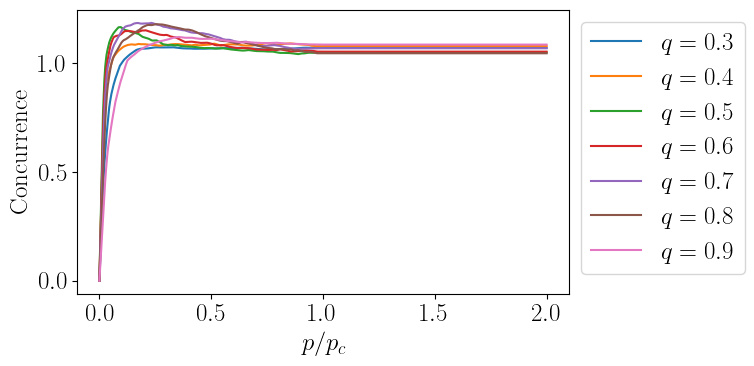

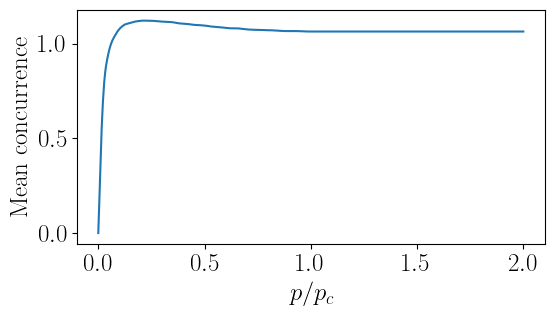

In [10]:
plt.figure(figsize=(8, 4))
for prob_i in range(len(prob_list)):
    plt.plot(p_c_bins, mean_means_cut[prob_i], label=rf"$q={prob_list[prob_i]}$") # 
# plt.xscale("log")
# plt.yscale("log")
plt.xlabel(r"$p/p_c$")
plt.ylabel(r"Concurrence")
plt.legend(bbox_to_anchor=(1, 1))
plt.tight_layout()
# plt.savefig("/home/investigator/Work/qaoa-qfi/Results/" + "QFI_BP_CUT.pdf", transparent=True, bbox_inches='tight')
plt.show()

plt.figure(figsize=(6, 3.5))
plt.plot(p_c_bins, np.mean(mean_means_cut, axis=0)) # 
# plt.xscale("log")
# plt.yscale("log")
plt.xlabel(r"$p/p_c$")
plt.ylabel(r"Mean concurrence")
plt.tight_layout()
# plt.savefig("/home/investigator/Work/qaoa-qfi/Results/" + "QFI_BP_CUT.pdf", transparent=True, bbox_inches='tight')
plt.show()

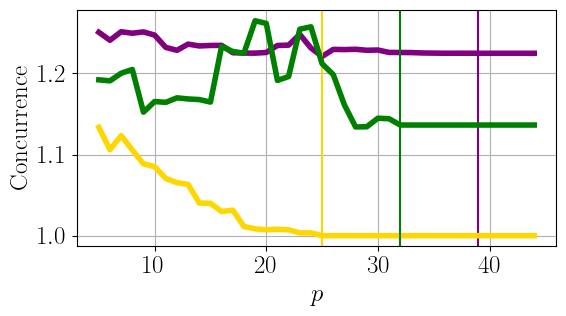

In [11]:
path = "/home/investigator/Work/qaoa-qfi/Data/Raw/Raw/CUT/Random_graphs/"
pref = "maxcut-random_graphs-"
post = "-prevsol" 

prob_i = 2
ss = [21, 3, 7]
rr = [8, 9, 7]
# colors = ["blue", "tab:blue", "navy"]
colors = ["purple", "gold", "green"]

sta = 5
fin = 45

plt.figure(figsize=(6, 3.5))
for i, (s, r) in enumerate(zip(ss, rr)):
    folder = 'n=%d-prob=%.2f-p=(%d,%d)-prevsol/' %(n, prob_list[prob_i], p_min_cut, p_max_cut)
    file_name = path + folder + pref + "n=%d-prob=%.2f-p=(%d,%d)-s=%d-r=%d" %(n, prob_list[prob_i], p_min_cut, p_max_cut, s, r) + post + ".npy"
    _, _, _, _, _, _, _, H_diag_r, _, _, _, _, _, _, xfs_r, EQD_r = np.load(file_name, allow_pickle=True)
    for p_i in range(p_max_cut - p_min_cut + 1):
        if np.linalg.norm(xfs_r[p_i]) < 1e-9:
            break
            
    plt.plot(arange(p_min_cut - 1, p_max_cut + 1)[sta:fin], np.concatenate([[0], ent_list_cut[prob_i][s][r]])[sta:fin], color=colors[i], linewidth=4)
    # plt.axvline(EQD_r/2, color=colors[i], linestyle="dashed")
    plt.axvline(p_i, color=colors[i], linestyle="solid")
plt.xlabel(r"$p$")
plt.ylabel(r"Concurrence")
# plt.ylim(0, 1.5)
plt.tight_layout()
plt.grid()
# plt.savefig("/home/investigator/Work/qaoa-qfi/Results/" + "cut-three_entanglements.pdf", transparent=True, bbox_inches='tight')
plt.show()

# SAT

In [15]:
m_list = arange(2, 2*n + 1, 2)
k = 2

s_min_sat = 0
s_max_sat = 49
r_min_sat = 0
r_max_sat = 49
p_min_sat = 1
p_max_sat = 150

In [16]:
# path = "/home/investigator/Work/qaoa-qfi/Data/Raw/Raw/SAT/"
# pref = "sat-"
# post = "-prevsol" 

# ent_list_sat = zeros([len(m_list), s_max_sat - s_min_sat + 1, r_max_sat - r_min_sat + 1, p_max_sat - p_min_sat + 1])
# EQD_list_sat = zeros([len(m_list), s_max_sat - s_min_sat + 1, r_max_sat - r_min_sat + 1])

# for m_i in range(len(m_list)):
#     folder = pref + r'n=%d-k=%d-m=(%d,%d)-p=(%d,%d)-s=(%d,%d)-r=(%d,%d)' %(n, k, m_list[0], m_list[-1], p_min_sat, p_max_sat, s_min_sat, s_max_sat, r_min_sat, r_max_sat) + post + "/"
#     for s in range(s_min_sat, s_max_sat + 1):
#         for r in range(r_min_sat, r_max_sat + 1):
#             print("m=%d | s=%d | r=%d" %(m_list[m_i], s, r), end="\r")
#             try:
#                 file_name = path + folder + pref + "n=%d-k=%d-m=%d-p=(%d,%d)-s=%d-r=%d" %(n, k, m_list[m_i], p_min_sat, p_max_sat, s, r) + post + ".npy"
#                 _, _, _, _, _, _, _, H_diag_r, _, _, _, _, _, _, xfs_r, EQD_r = np.load(file_name, allow_pickle=True)
#                 EQD_list_sat[m_i][s][r] = EQD_r
#             except:
#                 print("\tNo data for (m=%d, s=%d, r=%d)" %(m_list[m_i], s, r))
#                 EQD_list[m_i][s][r] = 2**n
#             xfs_r_cop = list(xfs_r)
#             for p_i in range(p_max_sat - p_min_sat + 1):
#                 if np.linalg.norm(xfs_r_cop[p_i]) < 1e-9:
#                     xfs_r_cop[p_i][:2*p_i] = xfs_r_cop[p_i - 1]
#                 sv = qfi.qaoa_vec(xfs_r_cop[p_i], n, x_list, H_diag_r, state_ini)
#                 ent_list_sat[m_i][s][r][p_i] = concurrence_pure(sv)

# p_c_list_sat = np.floor(np.max(EQD_list_sat, axis=2)/2)

# ent_list_sat[np.isnan(ent_list_sat)] = 0
### np.save("/home/investigator/Work/qaoa-qfi/Data/sat-concurrences-n=7-k=2-m=(2,14)-p=(1,150)-s=(0,49)-r=(0,49)-prevsol", ent_list_sat)

In [17]:
path = "/home/investigator/Work/qaoa-qfi/Data/"
post = "-prevsol" 
file_name = path + "sat-" + f"n={n}-k={k}-m=({m_list[0]},{m_list[-1]})-p=({p_min_sat},{p_max_sat})-s=({s_min_sat},{s_max_sat})-r=({r_min_sat},{r_max_sat})" + post 

with open(file_name + ".dict", 'rb') as fp:
    data_dict = pickle.load(fp)
data_dict.keys()

ent_list_sat = np.load("/home/investigator/Work/qaoa-qfi/Data/sat-concurrences-n=7-k=2-m=(2,14)-p=(1,150)-s=(0,49)-r=(0,49)-prevsol.npy")

errors_list_sat = data_dict["errors_list"]
EQD_list_sat = data_dict["EQD_list"]
p_c_list_sat = np.floor(np.max(EQD_list_sat, axis=2)/2)

error_threshold = 1e-8
subst = 1000 # some large p

mask_below_thr_sat = errors_list_sat < error_threshold

indices_below_thr_sat = np.where(mask_below_thr_sat.any(axis=-1), mask_below_thr_sat.argmax(axis=-1), subst) # put something large if no convergence
indices_no_conv_sat = np.where(np.all(indices_below_thr_sat == subst, axis=2))

p_smallest_sat = errors_list_sat[indices_no_conv_sat].argmin(axis=2)
indices_smallest_no_conv_sat = p_smallest_sat.argmin(axis=1)
indices_below_thr_sat[indices_no_conv_sat] = np.tile(indices_smallest_no_conv_sat, (s_max_sat - s_min_sat + 1, 1)).T

indices_below_thr_s_sat = indices_below_thr_sat.argmin(axis=2)
p_stars_sat = np.min(indices_below_thr_sat, axis=-1) + 1

/tmp/ipykernel_3900205/3384497588.py:6: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  data_dict = pickle.load(fp)


In [18]:
ent_list_sat_picked = np.zeros([len(m_list), s_max_sat - s_min_sat + 1, p_max_sat - p_min_sat + 1])
for m_i in range(len(m_list)):
    line_i = np.zeros([s_max_sat - s_min_sat + 1, p_max_sat - p_min_sat + 1])
    for s in range(s_max_sat - s_min_sat + 1):
        ind_i = indices_below_thr_s_sat[m_i][s]
        line_i[s] = ent_list_sat[m_i][s][ind_i]
    ent_list_sat_picked[m_i] = line_i

In [19]:
n_bins = 1000
p_c_bins = linspace(1e-2, 2, n_bins + 1)
n_instances = s_max_sat - s_min_sat + 1

### with bins
# mean_means = []
# mean_stds = []
# for n_i in range(len(n_list)):
#     p_max = 2**(n_list[n_i] - 0) + 10
#     ppcs = np.stack([np.arange(1, p_max + 1)]*n_instances).T/p_c_list[n_i]
#     means_i = np.mean(grad_gamma_0_vals[n_i], axis=2)
#     mean_means_n = []
#     mean_stds_n = []
#     for bi in p_c_bins:b
#         inds = np.argmin(np.abs(ppcs - bi), axis=0)
#         mean_means_i = np.mean(means_i[arange(n_instances), inds])
#         mean_stds_i = np.std(means_i[arange(n_instances), inds])
#         mean_means_n.append(mean_means_i)
#         mean_stds_n.append(mean_stds_i)
#     mean_means.append(mean_means_n)
#     mean_stds.append(mean_stds_n)
# mean_means = np.array(mean_means)
# mean_stds = np.array(mean_stds)

mean_means_sat = []
p_c_bins = np.insert(p_c_bins, 0, 0)
for m_i in range(len(m_list)):
    ppcs = np.stack([np.arange(1, p_max_sat - p_min_sat + 1 + 1)]*n_instances).T/p_c_list_sat[m_i]
    ppcs = np.insert(ppcs, 0, 0, axis=0)
    ppcs = ppcs.T
    prep = np.insert(ent_list_sat_picked[m_i], 0, 0, axis=1)
    iterps = []
    for pc_line, prep_line in zip(ppcs, prep):
        iterps.append(np.interp(p_c_bins, pc_line, prep_line))
    mean_means_sat.append(np.mean(iterps, axis=0))

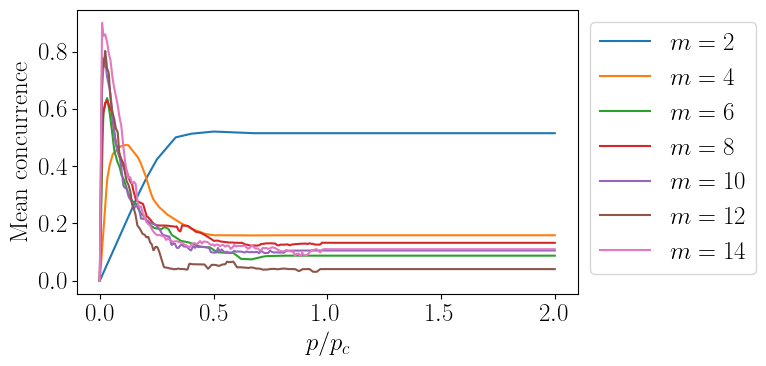

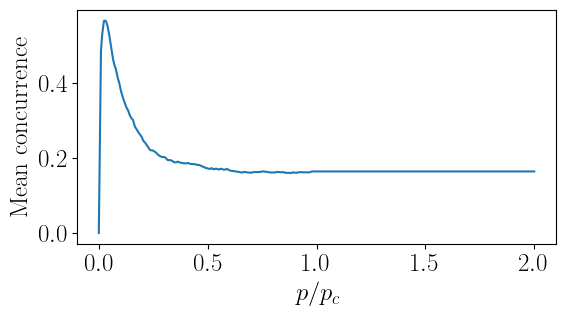

In [20]:
plt.figure(figsize=(8, 4))
for m_i in range(len(m_list)):
    plt.plot(p_c_bins, mean_means_sat[m_i], label=rf"$m={m_list[m_i]}$") # 
# plt.xscale("log")
# plt.yscale("log")
plt.xlabel(r"$p/p_c$")
plt.ylabel(r"Mean concurrence")
plt.legend(bbox_to_anchor=(1, 1))
plt.tight_layout()
# plt.savefig("/home/investigator/Work/qaoa-qfi/Results/" + ".pdf", transparent=True, bbox_inches='tight')
plt.show()

plt.figure(figsize=(6, 3.5))
plt.plot(p_c_bins, np.mean(mean_means_sat, axis=0)) # 
# plt.xscale("log")
# plt.yscale("log")
plt.xlabel(r"$p/p_c$")
plt.ylabel(r"Mean concurrence")
plt.tight_layout()
# plt.savefig("/home/investigator/Work/qaoa-qfi/Results/" + ".pdf", transparent=True, bbox_inches='tight')
plt.show()

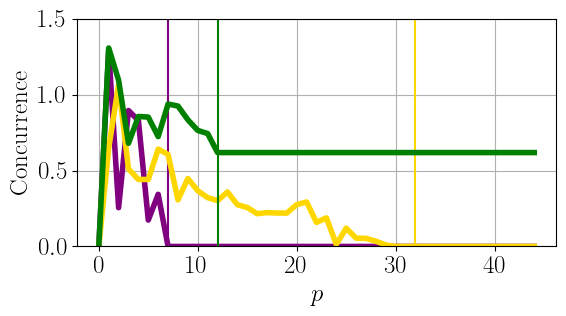

In [23]:
path = "/home/investigator/Work/qaoa-qfi/Data/Raw/Raw/SAT/"
pref = "sat-"
post = "-prevsol" 

m_i = -1
ss = [0, 2, 24]
rr = [6, 43, 20]
# colors = ["blue", "tab:blue", "navy"]
colors = ["purple", "gold", "green", "yellow", "cyan", "black"]

fin = 45

plt.figure(figsize=(6, 3.5))
for i, (s, r) in enumerate(zip(ss, rr)):
    folder = pref + r'n=%d-k=%d-m=(%d,%d)-p=(%d,%d)-s=(%d,%d)-r=(%d,%d)' %(n, k, m_list[0], m_list[-1], p_min_sat, p_max_sat, s_min_sat, s_max_sat, r_min_sat, r_max_sat) + post + "/"
    file_name = path + folder + pref + "n=%d-k=%d-m=%d-p=(%d,%d)-s=%d-r=%d" %(n, k, m_list[m_i], p_min_sat, p_max_sat, s, r) + post + ".npy"
    _, _, _, _, _, _, _, H_diag_r, _, _, _, _, _, _, xfs_r, EQD_r = np.load(file_name, allow_pickle=True)
    for p_i in range(p_max_sat - p_min_sat + 1):
        if np.linalg.norm(xfs_r[p_i]) < 1e-9:
            break
            
    plt.plot(arange(p_min_sat - 1, p_max_sat + 1)[:fin], np.concatenate([[0], ent_list_sat[m_i][s][r]])[:fin], color=colors[i], linewidth=4)
    # plt.axvline(EQD_r/2, color=colors[i], linestyle="dashed")
    plt.axvline(p_i, color=colors[i], linestyle="solid")
plt.xlabel(r"$p$")
plt.ylabel(r"Concurrence")
plt.ylim(0, 1.5)
plt.tight_layout()
plt.grid()
# plt.savefig("/home/investigator/Work/qaoa-qfi/Results/" + "sat-three_entanglements.pdf", transparent=True, bbox_inches='tight')
plt.show()

# CUT and SAT

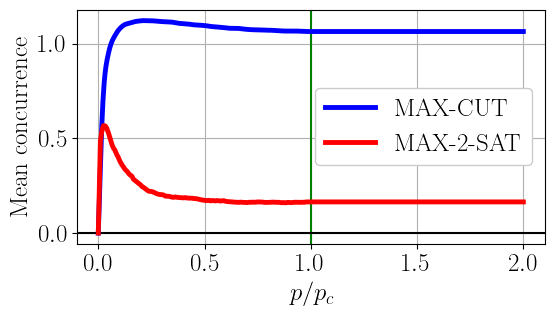

In [24]:
plt.figure(figsize=(6, 3.5))
plt.axvline(1, color="green")
plt.axhline(0, color="black")
plt.plot(p_c_bins, np.mean(mean_means_cut, axis=0), linewidth=3.5, color="blue", label="MAX-CUT") # 
plt.plot(p_c_bins, np.mean(mean_means_sat, axis=0), linewidth=3.5, color="red", label="MAX-2-SAT") # 
plt.xlabel(r"$p/p_c$")
plt.ylabel(r"Mean concurrence")
plt.tight_layout()
plt.legend(framealpha=1)
plt.grid()
# plt.savefig("/home/investigator/Work/qaoa-qfi/Results/" + "sat-cut-entanglement.pdf", transparent=True, bbox_inches='tight')
plt.show()

# Checks

m=0.5 | s=0 | r=0

Exact GS:
	Energy: -4
	Degeneracy: 26

Found GS:
	Energy: -3.9999999999963776
	Entanglement: 1.2525390309481748

	vector:
		|0000111> * (-0.030367209222035486+0.12743840074012686j)
		|0001011> * (-0.030367209222035455+0.12743840074012705j)
		|0001100> * (-0.21275975130698926+0.10790994678192367j)
		|0001101> * (0.11005145618507614-0.15759230219132125j)
		|0010011> * (0.2919443411757282-0.22170190011406526j)
		|0010101> * (-0.030367209222035514+0.12743840074012697j)
		|0011001> * (-0.030367209222035507+0.1274384007401271j)
		|0100110> * (0.12882178548550371-0.14229266386413483j)
		|0100111> * (0.1288217854855036-0.14229266386413475j)
		|0101100> * (-0.041613677563685204-0.161671852487389j)
		|0110011> * (-0.04161367756368516-0.16167185248738905j)
		|0110100> * (0.12882178548550377-0.1422926638641349j)
		|0110101> * (0.12882178548550374-0.1422926638641347j)
		|1001010> * (0.12882178548550374-0.1422926638641347j)
		|1001011> * (0.12882178548550377-0.1422926638641349j)
	

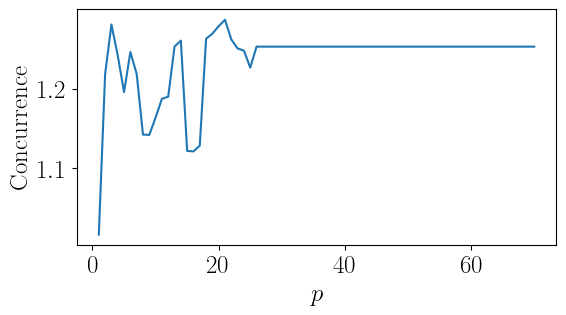

In [25]:
path = "/home/investigator/Work/qaoa-qfi/Data/Raw/Raw/CUT/Random_graphs/"
pref = "maxcut-random_graphs-"
post = "-prevsol" 

prob_i = 2
s = 0
r = 0

folder = 'n=%d-prob=%.2f-p=(%d,%d)-prevsol/' %(n, prob_list[prob_i], p_min_cut, p_max_cut)
file_name = path + folder + pref + "n=%d-prob=%.2f-p=(%d,%d)-s=%d-r=%d" %(n, prob_list[prob_i], p_min_cut, p_max_cut, s, r) + post + ".npy"
_, _, _, _, _, _, _, H_diag_r, _, _, _, _, _, _, xfs_r, _ = np.load(file_name, allow_pickle=True)
for p_i in range(p_max_cut - p_min_cut + 1):
    if np.linalg.norm(xfs_r[p_i]) < 1e-9:
        break
sv = qfi.qaoa_vec(xfs_r[p_i - 1], n, x_list, H_diag_r, state_ini)
ent = concurrence_pure(sv)

print(f"m={prob_list[prob_i]} | s={s} | r={r}\n")

print("Exact GS:")
print(f"\tEnergy: {min(H_diag_r)}")
print(f"\tDegeneracy: {np.count_nonzero(H_diag_r == np.min(H_diag_r))}\n")

print("Found GS:")
print(f"\tEnergy: {(sv.conj()@(H_diag_r*sv)).real}")
print(f"\tEntanglement: {ent}\n")
print("\tvector:")
for i in range(2**n):
    if np.abs(sv[i]) > 1e-4:
        bs_bin = bin(i)[2:]
        bs_bin = "|" + "0"*(n - len(bs_bin)) + bs_bin + ">"
        print(f"\t\t{bs_bin} * {sv[i]}")
        
plt.figure(figsize=(6, 3.5))
plt.plot(arange(p_min_cut, p_max_cut + 1), ent_list_cut[prob_i][s][r])
plt.xlabel(r"$p$")
plt.ylabel(r"Concurrence")
plt.tight_layout()
plt.show()

m=14 | s=24 | r=20

Exact GS:
	Energy: 0.0
	Degeneracy: 4

Found GS:
	Energy: 2.5238828459058853e-12
	Entanglement: 0.6180346289193424



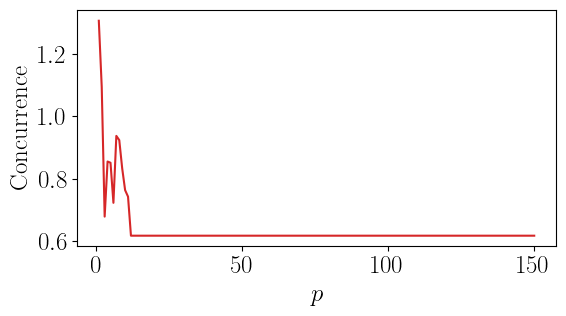

In [26]:
path = "/home/investigator/Work/qaoa-qfi/Data/Raw/Raw/SAT/"
pref = "sat-"
post = "-prevsol" 

m_i = -1
s = 24
r = 20

folder = pref + r'n=%d-k=%d-m=(%d,%d)-p=(%d,%d)-s=(%d,%d)-r=(%d,%d)' %(n, k, m_list[0], m_list[-1], p_min_sat, p_max_sat, s_min_sat, s_max_sat, r_min_sat, r_max_sat) + post + "/"
file_name = path + folder + pref + "n=%d-k=%d-m=%d-p=(%d,%d)-s=%d-r=%d" %(n, k, m_list[m_i], p_min_sat, p_max_sat, s, r) + post + ".npy"
_, _, _, _, _, _, _, H_diag_r, _, _, _, _, _, _, xfs_r, _ = np.load(file_name, allow_pickle=True)
for p_i in range(p_max_sat - p_min_sat + 1):
    if np.linalg.norm(xfs_r[p_i]) < 1e-9:
        break
sv = qfi.qaoa_vec(xfs_r[p_i - 1], n, x_list, H_diag_r, state_ini)
ent = concurrence_pure(sv)

print(f"m={m_list[m_i]} | s={s} | r={r}\n")

print("Exact GS:")
print(f"\tEnergy: {min(H_diag_r)}")
print(f"\tDegeneracy: {np.count_nonzero(H_diag_r == np.min(H_diag_r))}\n")

print("Found GS:")
print(f"\tEnergy: {(sv.conj()@(H_diag_r*sv)).real}")
print(f"\tEntanglement: {ent}\n")
# print("\tvector:")
# for i in range(2**n):
#     if np.abs(sv[i]) > 1e-4:
#         bs_bin = bin(i)[2:]
#         bs_bin = "|" + "0"*(n - len(bs_bin)) + bs_bin + ">"
#         print(f"\t\t{bs_bin} * {sv[i]}")
        
plt.figure(figsize=(6, 3.5))
plt.plot(arange(p_min_sat, p_max_sat + 1), ent_list_sat[m_i][s][r], color="tab:red")
plt.xlabel(r"$p$")
plt.ylabel(r"Concurrence")
plt.tight_layout()
plt.show()